In [1]:
import itertools
import math
from typing import Callable

import joblib
import numpy as np
import scipy as sp
import pandas as pd
import nibabel as nib
import bct
import matplotlib.pyplot as plt 
import seaborn as sns
import colorcet
from statsmodels.stats.multitest import fdrcorrection
import pingouin as pg

import pymcm

plt.rcParams["font.family"] = "monospace"

In [3]:
group = joblib.load('/RAID1/jupytertmp/mcm/data/2July2024_base.joblib')

# Compare different combinations of parameters

- DC
    - sum(pfc)
    - sum(fc)
    - none
- FC
    - pfc
    - fc
    - none
- SC
    - sc > 0
    - top 25%
    - none

In [4]:
names = ['-'.join(x) for x in itertools.product(['spfc', 'sfc', 'none'], ['pfc', 'fc', 'none'], ['sc>0', '25%', 'none'])]

names_pretty = [' '.join(x) for x in itertools.product(
    ['ΣpFC', 'ΣFC ', '∅   '], 
    ['pFC ', 'FC  ', '∅   '], 
    ['CS>0', '25% ', '∅   '])]

In [5]:
n = group['roi_template'].size
logratio_proc = pymcm.proc.PetRatio()

for sub in group.iterraw():

    parameters = itertools.product(
        [sub['pfc'].sum(axis=0), sub['fc'].sum(axis=0), np.ones(n)],
        [sub['pfc'], sub['fc'], np.ones([n,n])],
        [sub['sc'] > 0, bct.threshold_proportional(sub['sc'], 0.25, copy=True), np.ones([n,n])]
    )

    for name, (dc, fc, sc) in zip(names, parameters):

        cmrglc_adj = sub.pet['roiavgs'] / dc
        logratio = logratio_proc.fit_transform(cmrglc_adj)
        logratio_scaled = pymcm.scale(logratio, -1, 1)

        dir_weight = np.where(logratio_scaled < 0, np.abs(logratio_scaled), 0)
        undir_weight = 1 - (np.abs(logratio_scaled))

        directed = fc  * dir_weight * sc
        undirected = fc  * undir_weight * sc

        labels, average, percent_in, percent_out = pymcm.matrix_grouped_average(directed, group['net_template'])

        sub.add_deriv(f'directed_{name}', directed)
        sub.add_deriv(f'undirected_{name}', undirected)
        sub.add_deriv(f'directed_net_{name}', average)
        sub.add_deriv(f'directed_net_degin_{name}', percent_in)
        sub.add_deriv(f'directed_net_degout_{name}', percent_out)

    print(sub.name, end='\r')

## Compute averages of directed and undirected

In [93]:
for name in names:

    average_directed = np.median([sub[f'directed_{name}'] for sub in group.iterraw()], axis=0)
    average_undirected = np.median([sub[f'undirected_{name}'] for sub in group.iterraw()], axis=0)
    group.add_deriv(f'avg_directed_{name}', average_directed)
    group.add_deriv(f'avg_undirected_{name}', average_undirected)

    directed_vec = pymcm.vectorize_matrix(average_directed)
    undirected_vec = pymcm.vectorize_matrix(average_undirected)
    group.add_deriv(f'vec_avg_directed_{name}', directed_vec)
    group.add_deriv(f'vec_avg_undirected_{name}', undirected_vec)

    average_directed_net = np.median([sub[f'directed_net_{name}'] for sub in group.iterraw()], axis=0)
    group.add_deriv(f'avg_directed_net_{name}', average_directed_net)

    average_percent_in = np.median([sub[f'directed_net_degin_{name}'] for sub in group.iterraw()], axis=0)
    average_percent_out = np.median([sub[f'directed_net_degout_{name}'] for sub in group.iterraw()], axis=0)
    group.add_deriv(f'avg_percent_in_{name}', average_percent_in)
    group.add_deriv(f'avg_percent_out_{name}', average_percent_out)

# t-tests

In [94]:
names_c = list(itertools.combinations(names, r=2))
indices_c = list(itertools.combinations(range(len(names)), r=2))

In [95]:
n = len(names)
k = 2
math.factorial(n) / (math.factorial(k) * math.factorial(n-k))

351.0

## directed


In [12]:
ttest_results = [
    sp.stats.ttest_ind(group[f'vec_avg_directed_{first}'], group[f'vec_avg_directed_{second}'], equal_var=False) for first, second in names_c
    ]
utest_results = [sp.stats.mannwhitneyu(group[f'vec_avg_directed_{first}'], group[f'vec_avg_directed_{second}']) for first, second in names_c]

correction = sp.stats.false_discovery_control([utest.pvalue for utest in utest_results], method='bh')
correction_sig = correction < 0.01

In [97]:
ttest_results = [
    sp.stats.ttest_ind(pymcm.vectorize_matrix(group[f'avg_directed_net_{first}']), pymcm.vectorize_matrix(group[f'avg_directed_net_{second}']), equal_var=False) for first, second in names_c
    ]
utest_results = [
    sp.stats.mannwhitneyu(pymcm.vectorize_matrix(group[f'avg_directed_net_{first}']), pymcm.vectorize_matrix(group[f'avg_directed_net_{second}'])) for first, second in names_c
    ]

correction = sp.stats.false_discovery_control([ttest.pvalue for ttest in ttest_results], method='bh')
correction_sig = correction < 0.01

In [101]:
ttest_results

[TtestResult(statistic=-0.1410613171127001, pvalue=0.8884881365543458, df=42.49153057062347),
 TtestResult(statistic=0.060275053657652566, pvalue=0.952145726606221, df=57.45976065281356),
 TtestResult(statistic=0.3385714513240163, pvalue=0.7362016752679891, df=55.87208509641394),
 TtestResult(statistic=-0.019399914522946066, pvalue=0.9846064659526153, df=45.73650965509861),
 TtestResult(statistic=0.33025497796236336, pvalue=0.7425076458931914, df=53.06521012519607),
 TtestResult(statistic=0.09369122481363211, pvalue=0.9256777565055752, df=57.92664758629271),
 TtestResult(statistic=-0.09863084866728856, pvalue=0.9218543319186059, df=46.61058737185693),
 TtestResult(statistic=0.06818504253581122, pvalue=0.9458729615660729, df=57.97407868396796),
 TtestResult(statistic=-0.12351995503170128, pvalue=0.9021737595602357, df=51.76254122101936),
 TtestResult(statistic=0.0028213478384835565, pvalue=0.9977616047410123, df=44.1439088654889),
 TtestResult(statistic=-0.16355954987836155, pvalue=0.87

In [98]:
stats = np.zeros([n, n])
pvalues = np.zeros([n, n])
# pvalues_corrected = np.zeros([n, n])
pvalues_mask = np.zeros([n, n])

for (i,j), ttest, sig in zip(indices_c, ttest_results, correction_sig):
    stats[i,j] = ttest.statistic
    pvalues[i,j] = ttest.pvalue
    pvalues_mask[i,j] = sig

stats += stats.T
pvalues += pvalues.T
# pvalues_corrected += pvalues_corrected.T
pvalues_mask += pvalues_mask.T
pvalues_mask = pvalues_mask.astype(bool)

In [99]:
stats_masked = stats.copy()
stats_masked[~pvalues_mask] = 0

stats_deg = np.sum(np.abs(stats_masked), axis=0)
sort_idcs = np.argsort(stats_deg)

stats_masked_sorted = stats_masked[np.ix_(sort_idcs, sort_idcs)]
names_pretty_sorted = np.array(names_pretty)[sort_idcs]

for name, deg in zip(names_pretty_sorted, stats_deg[sort_idcs]):
    print(f'{name:<30} {deg:<5}')

ΣpFC pFC  CS>0                 0.0  
ΣpFC pFC  25%                  0.0  
ΣpFC pFC  ∅                    0.0  
ΣpFC FC   CS>0                 0.0  
ΣpFC FC   25%                  0.0  
ΣpFC FC   ∅                    0.0  
ΣpFC ∅    CS>0                 0.0  
ΣpFC ∅    25%                  0.0  
ΣpFC ∅    ∅                    0.0  
ΣFC  pFC  CS>0                 0.0  
ΣFC  pFC  25%                  0.0  
ΣFC  pFC  ∅                    0.0  
ΣFC  FC   CS>0                 0.0  
ΣFC  FC   25%                  0.0  
ΣFC  FC   ∅                    0.0  
ΣFC  ∅    CS>0                 0.0  
ΣFC  ∅    25%                  0.0  
ΣFC  ∅    ∅                    0.0  
∅    pFC  CS>0                 0.0  
∅    pFC  25%                  0.0  
∅    pFC  ∅                    0.0  
∅    FC   CS>0                 0.0  
∅    FC   25%                  0.0  
∅    FC   ∅                    0.0  
∅    ∅    CS>0                 0.0  
∅    ∅    25%                  0.0  
∅    ∅    ∅                    0.0  


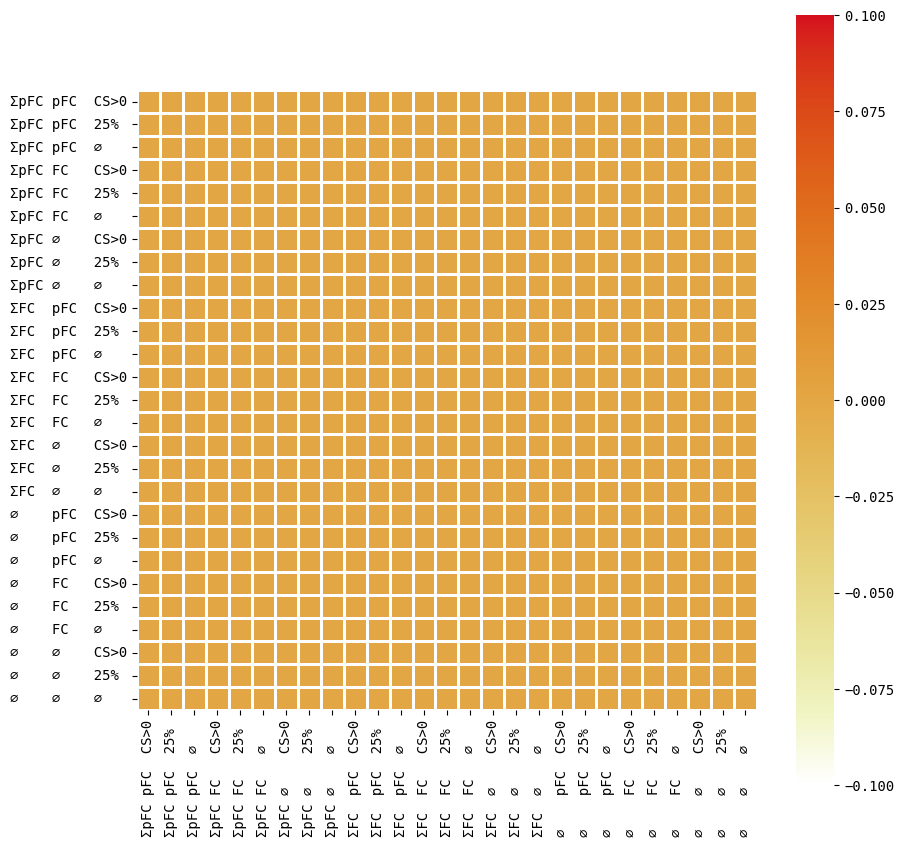

In [100]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
sns.heatmap(stats_masked_sorted, square=True, cbar=True, cmap='cet_CET_L18', ax=ax, linewidths=1)

ax.set(xticks=np.arange(len(names))+0.5, yticks=np.arange(len(names))+0.5)
ax.set_xticklabels(names_pretty_sorted, rotation=90)
ax.set_yticklabels(names_pretty_sorted, rotation=0);

---

# Intraclass correlation coefficient

In [20]:
data = pg.read_dataset('icc')

In [113]:
unique = np.unique(group['net_template'])
nets = np.concatenate([unique, unique])
directions = ['in' for _ in range(unique.size)] + ['out' for _ in range(unique.size)]
nets_ids = [net + '-' + dir for net, dir in zip(nets, directions)]

df = pd.concat([ 
    pd.DataFrame(dict(
        value=np.concatenate([ group[f'avg_percent_in_{name}'], group[f'avg_percent_out_{name}'] ]), 
        net_id=nets_ids,
        net=nets,
        direction=directions,
        method=name,
    )) for name in names ])

df[['cmrglc_adjustment', 'fc', 'sc']] = df['method'].str.split('-', expand=True)

In [114]:
icc = pg.intraclass_corr(data=df, targets='net_id', raters='method', ratings='value')
icc = icc.round(3).set_index('Type')
icc

,Description,ICC,F,df1,df2,pval,CI95%
Type,,,,,,,
ICC1,Single raters absolute,0.744,79.415,11,312,0.0,"[0.58, 0.89]"
ICC2,Single random raters,0.744,72.797,11,286,0.0,"[0.58, 0.89]"
ICC3,Single fixed raters,0.727,72.797,11,286,0.0,"[0.56, 0.89]"
ICC1k,Average raters absolute,0.987,79.415,11,312,0.0,"[0.97, 1.0]"
ICC2k,Average random raters,0.987,72.797,11,286,0.0,"[0.97, 1.0]"
ICC3k,Average fixed raters,0.986,72.797,11,286,0.0,"[0.97, 1.0]"


/tmp/ipykernel_2788478/2972216377.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


Text(0.5, 1.0, 'ICC = 0.727')

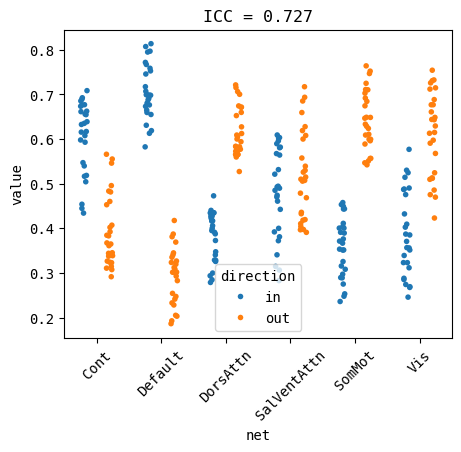

In [119]:
fig, ax = plt.subplots(figsize=(5,4))
sns.stripplot(data=df, x='net', y='value', hue='direction', ax=ax, size=4, dodge=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title(f'ICC = {icc.loc['ICC3', 'ICC']}')

/tmp/ipykernel_2788478/3130854013.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/tmp/ipykernel_2788478/3130854013.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/tmp/ipykernel_2788478/3130854013.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)


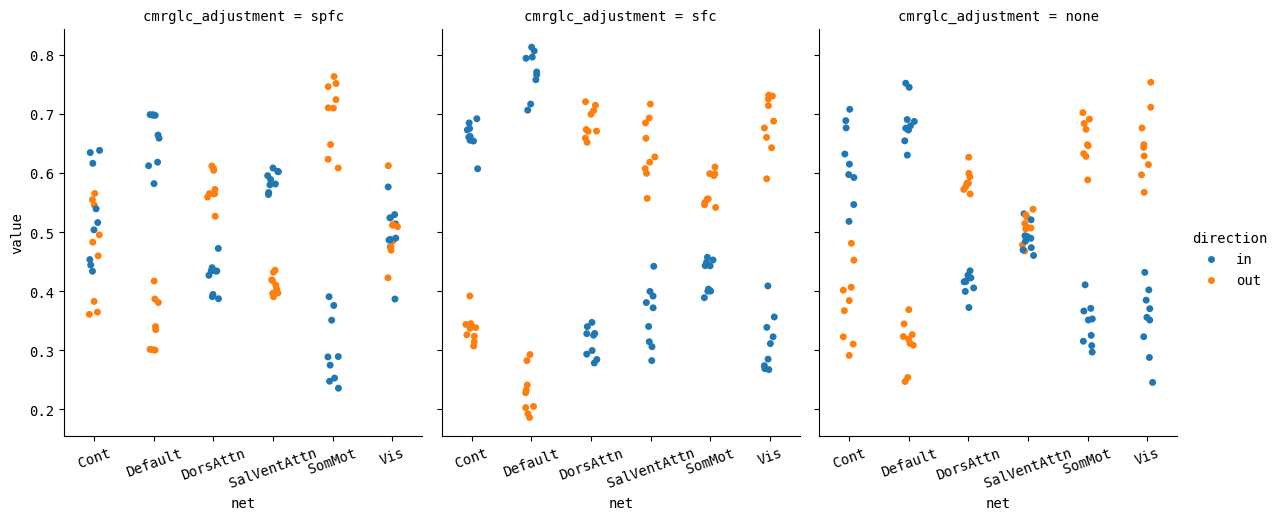

In [138]:
grid = sns.catplot(data=df, x='net', y='value', hue='direction', col='cmrglc_adjustment', aspect=0.8, kind='strip')
for ax in grid.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)

/tmp/ipykernel_2788478/4233213876.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/tmp/ipykernel_2788478/4233213876.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/tmp/ipykernel_2788478/4233213876.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)


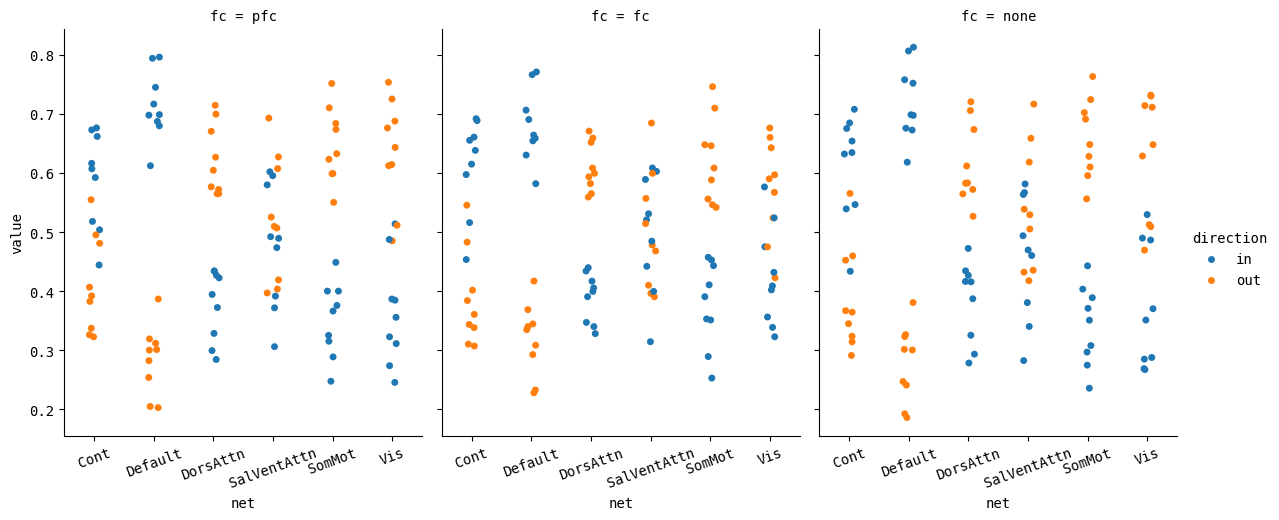

In [139]:
grid = sns.catplot(data=df, x='net', y='value', hue='direction', col='fc', aspect=0.8, kind='strip')
for ax in grid.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)

/tmp/ipykernel_2788478/4232854242.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/tmp/ipykernel_2788478/4232854242.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/tmp/ipykernel_2788478/4232854242.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)


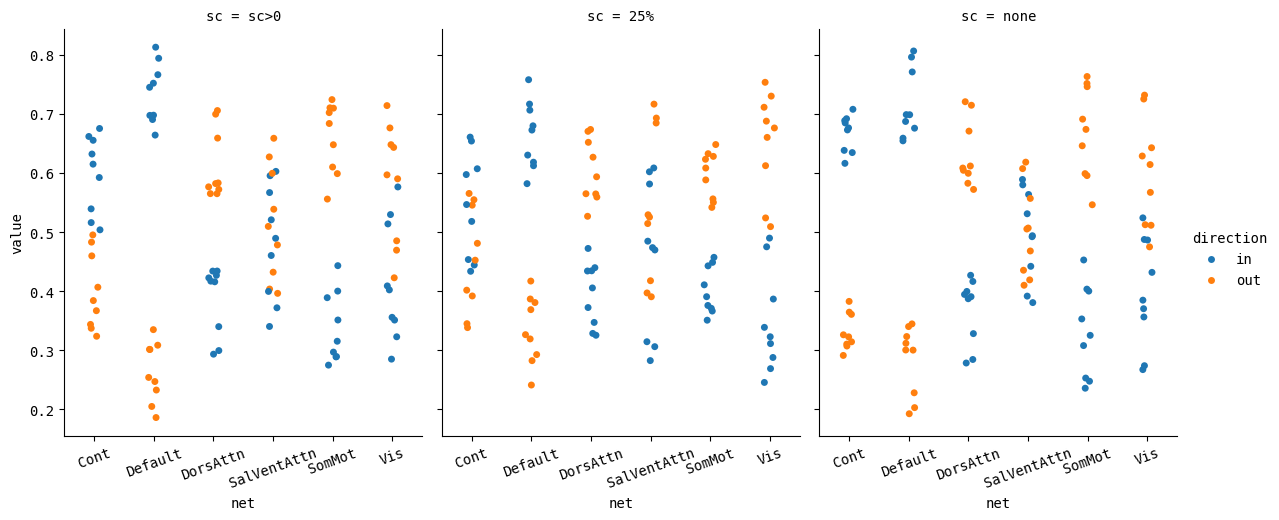

In [145]:
grid = sns.catplot(data=df, x='net', y='value', hue='direction', col='sc', aspect=0.8, kind='strip')
for ax in grid.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)